In [440]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import train_test_split, cross_val_score

In [441]:
train = pd.read_csv('./train.csv')
test = pd.read_csv('./test.csv')


In [442]:
test2 = pd.read_csv('./test.csv')

In [443]:
train2 =pd.read_csv('./train.csv')

In [444]:
train.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [445]:
train.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


数据集的统计

In [446]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [447]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [448]:
train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

训练集一共有1459条数据

缺失最严重：
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
（决定删掉这四列）

缺失较轻的
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81
GarageYrBlt,81
GarageCond,81
BsmtFinType2,38
BsmtExposure,38
BsmtCond,37
BsmtQual,37
BsmtFinType1,37
MasVnrArea,8
Electrical,1


In [449]:
test.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal
1458,2919,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,11,2006,WD,Normal


In [450]:
test.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

In [451]:
missing_percentage = (train.isnull().sum() / len(train)) * 100
filtered_missing_percentage = missing_percentage[missing_percentage >0]
print(filtered_missing_percentage)

LotFrontage     17.739726
Alley           93.767123
MasVnrType      59.726027
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
PoolQC          99.520548
Fence           80.753425
MiscFeature     96.301370
dtype: float64


In [452]:
#丢掉缺失值超过30的
train =train.drop('Id',axis=1)
test =test.drop('Id',axis=1)
train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [453]:
data_drop = ['PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu']
train=train.drop(data_drop,axis =1)
test =test.drop(data_drop,axis =1)

In [454]:
train.isnull().sum()


MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
Street             0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 74, dtype: int64

In [455]:
test.isnull().sum()

MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
Street             0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 73, dtype: int64

In [456]:
train['LotFrontage'].dtype

dtype('float64')

In [457]:
train['LotFrontage'].head(5)

0    65.0
1    80.0
2    68.0
3    60.0
4    84.0
Name: LotFrontage, dtype: float64

<Axes: xlabel='LotFrontage', ylabel='Count'>

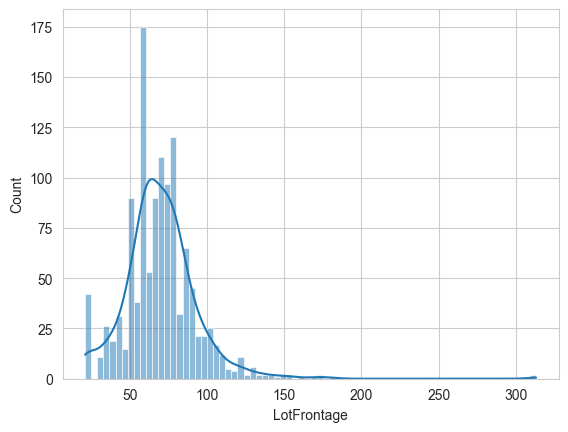

In [458]:
sb.histplot(train['LotFrontage'],kde=True)

In [459]:
# 通过MSSubClass 分组进行填充缺失值
train['LotFrontage']=train.groupby('MSSubClass')['LotFrontage'].transform(lambda x:x.fillna(x.median()))

In [460]:
# 训练集计算中位数
train_lotfrontage_median = train.groupby('MSSubClass')['LotFrontage'].median()
# 测试集用训练集的中位数填充
test['LotFrontage'] = test.groupby('MSSubClass')['LotFrontage'].transform(
    lambda x: x.fillna(x.map(train_lotfrontage_median))
)

In [461]:
# 检验缺失值
train['LotFrontage'].isnull().sum()

np.int64(0)

In [462]:
test['LotFrontage'].isnull().sum()

np.int64(227)

In [463]:
#处理garage类的缺失值
garage = ['GarageType','GarageQual','GarageCond','GarageFinish']
for column in garage:
    print(column)
    print(train[column].dtype)

GarageType
object
GarageQual
object
GarageCond
object
GarageFinish
object


In [464]:
train[garage] = train[garage].fillna('None')
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)

test[garage] = train[garage].fillna('None')
test['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)

In [465]:
# 地下车库填充
missing_row=train[train['BsmtFinType2'].isnull()][['BsmtFinType2', 'BsmtExposure', 'BsmtQual', 'BsmtFinType1', 'BsmtCond']]
print(missing_row)

     BsmtFinType2 BsmtExposure BsmtQual BsmtFinType1 BsmtCond
17            NaN          NaN      NaN          NaN      NaN
39            NaN          NaN      NaN          NaN      NaN
90            NaN          NaN      NaN          NaN      NaN
102           NaN          NaN      NaN          NaN      NaN
156           NaN          NaN      NaN          NaN      NaN
182           NaN          NaN      NaN          NaN      NaN
259           NaN          NaN      NaN          NaN      NaN
332           NaN           No       Gd          GLQ       TA
342           NaN          NaN      NaN          NaN      NaN
362           NaN          NaN      NaN          NaN      NaN
371           NaN          NaN      NaN          NaN      NaN
392           NaN          NaN      NaN          NaN      NaN
520           NaN          NaN      NaN          NaN      NaN
532           NaN          NaN      NaN          NaN      NaN
533           NaN          NaN      NaN          NaN      NaN
553     

In [466]:
bsmt_cat_cols = ['BsmtFinType2', 'BsmtExposure', 'BsmtQual', 'BsmtFinType1', 'BsmtCond']
train[bsmt_cat_cols] = train[bsmt_cat_cols].fillna('None')
test[bsmt_cat_cols] = test[bsmt_cat_cols].fillna('None')


# 如果有地下室面积等数值特征（如BsmtFinSF1），填充0
# train['BsmtFinSF1'] = train['BsmtFinSF1'].fillna(0)

In [467]:
# MasVnrArea
# 数值变量填充 0
train['MasVnrArea'] = train['MasVnrArea'].fillna(0)
test['MasVnrArea'] = test['MasVnrArea'].fillna(0)

In [468]:
train.dropna(subset=['Electrical'], inplace=True)

In [469]:
train.isnull().sum()

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 74, dtype: int64

In [470]:
test.isnull().sum()

MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
Street             0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 73, dtype: int64

In [471]:
test_miss =[
    "MSZoning","Utilities","Functional","BsmtFullBath","BsmtHalfBath","BsmtFinSF1","Exterior1st","TotalBsmtSF","Exterior2nd","BsmtFinSF2",
    "KitchenQual",
    "GarageCars",
    "SaleType",
    "GarageArea",
    "BsmtUnfSF"
]
for column in test_miss:
    print(column)
    print(test[column].dtype)


MSZoning
object
Utilities
object
Functional
object
BsmtFullBath
float64
BsmtHalfBath
float64
BsmtFinSF1
float64
Exterior1st
object
TotalBsmtSF
float64
Exterior2nd
object
BsmtFinSF2
float64
KitchenQual
object
GarageCars
float64
SaleType
object
GarageArea
float64
BsmtUnfSF
float64


In [472]:
train_mode = train[['MSZoning','Exterior1st','Exterior2nd','SaleType','Functional','KitchenQual']].mode().iloc[0]

train_median = train[['BsmtFullBath','BsmtHalfBath','TotalBsmtSF','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','GarageCars','GarageArea']].median()

# 分类特征用训练集众数填充
test[['MSZoning','Exterior1st','Exterior2nd','SaleType','Functional','KitchenQual']]=test[['MSZoning','Exterior1st','Exterior2nd','SaleType','Functional','KitchenQual']].fillna(train_mode)

# 数值特征按逻辑填充
for col in ['BsmtFullBath', 'BsmtHalfBath', 'TotalBsmtSF', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']:
    # 条件：地下室存在
    mask = (test['BsmtQual'] != 'None') & (test[col].isnull())
    test.loc[mask,col] = train_median[col]
    test[col].fillna(0)

for col in ['GarageCars','GarageArea']:
    mask = (test['GarageType'] != 'None' ) & (test[col].isnull())
    test.loc[mask,col] = train_median[col]
    test[col].fillna(0)

In [473]:
train['Street'].unique()

array(['Pave', 'Grvl'], dtype=object)

In [474]:
print("测试集剩余缺失值：")
print(test.isnull().sum())

测试集剩余缺失值：
MSSubClass         0
MSZoning           0
LotFrontage      227
LotArea            0
Street             0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
Length: 73, dtype: int64


In [475]:
for column in train.columns:
    print(column)
    print(train[column].dtype)

MSSubClass
int64
MSZoning
object
LotFrontage
float64
LotArea
int64
Street
object
LotShape
object
LandContour
object
Utilities
object
LotConfig
object
LandSlope
object
Neighborhood
object
Condition1
object
Condition2
object
BldgType
object
HouseStyle
object
OverallQual
int64
OverallCond
int64
YearBuilt
int64
YearRemodAdd
int64
RoofStyle
object
RoofMatl
object
Exterior1st
object
Exterior2nd
object
MasVnrArea
float64
ExterQual
object
ExterCond
object
Foundation
object
BsmtQual
object
BsmtCond
object
BsmtExposure
object
BsmtFinType1
object
BsmtFinSF1
int64
BsmtFinType2
object
BsmtFinSF2
int64
BsmtUnfSF
int64
TotalBsmtSF
int64
Heating
object
HeatingQC
object
CentralAir
object
Electrical
object
1stFlrSF
int64
2ndFlrSF
int64
LowQualFinSF
int64
GrLivArea
int64
BsmtFullBath
int64
BsmtHalfBath
int64
FullBath
int64
HalfBath
int64
BedroomAbvGr
int64
KitchenAbvGr
int64
KitchenQual
object
TotRmsAbvGrd
int64
Functional
object
Fireplaces
int64
GarageType
object
GarageYrBlt
float64
GarageFinish
object


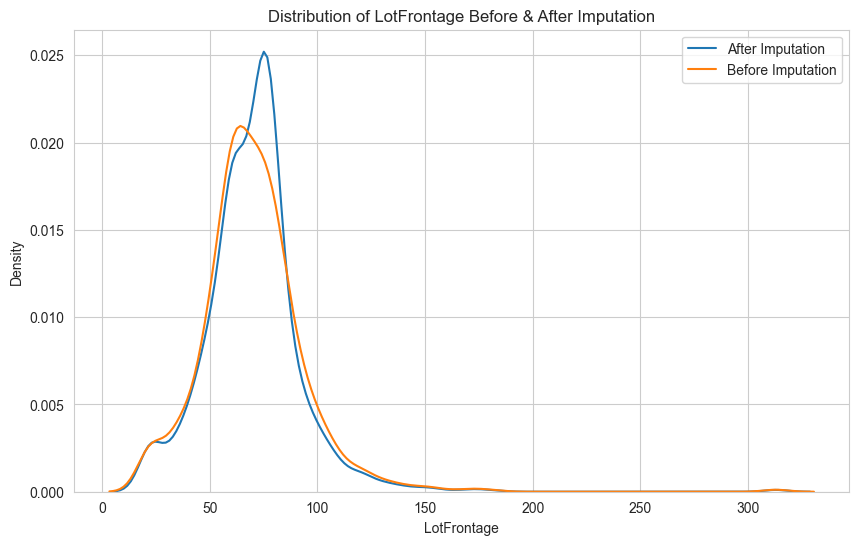

GarageType
Attchd     870
Detchd     387
BuiltIn     87
None        81
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64


In [476]:
# 数值型字段：对比填充前后分布（以 TotalBsmtSF 为例）
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(train['LotFrontage'], label='After Imputation')
sns.kdeplot(train2['LotFrontage'], label='Before Imputation')  # 原始数据需保留
plt.legend()
plt.title('Distribution of LotFrontage Before & After Imputation')
plt.show()

# 分类型字段：检查填充后的众数合理性（以 GarageType 为例）
print(train['GarageType'].value_counts(dropna=False))

In [477]:
train['Neighborhood'].head(3)

0    CollgCr
1    Veenker
2    CollgCr
Name: Neighborhood, dtype: object

In [478]:
# 对字符串数据进行处理
train['MSZoning'].unique()


array(['RL', 'RM', 'C (all)', 'FV', 'RH'], dtype=object)

In [479]:
# 查看所有为字符串类型的列
cat_cols1 = train.select_dtypes(include = 'object').columns.tolist()
print(cat_cols1)

['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


In [480]:
# 1 标签编码
# 适用于无序列表，且类别数量较少
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['MSZoning'] = le.fit_transform(train['MSZoning'].astype(str))

test['MSZoning'] = le.fit_transform(test['MSZoning'].astype(str))

In [481]:
train['Street'].unique()

array(['Pave', 'Grvl'], dtype=object)

In [482]:
# 2 独热编码
# 适用于无序，且类别较多的
# 转换前重置索引（推荐）
train_reset = train.reset_index(drop=True)
train_encoded = ohe.fit_transform(train_reset[['Neighborhood', 'HouseStyle']])

# 合并时也使用重置后的索引
encoded_df = pd.DataFrame(train_encoded, columns=ohe.get_feature_names_out())
train = pd.concat([
    train_reset.drop(['Neighborhood', 'HouseStyle'], axis=1),
    encoded_df
], axis=1)

In [483]:
train['Street'].unique()

array(['Pave', 'Grvl'], dtype=object)

In [484]:
test_encoded = ohe.transform(test[['Neighborhood', 'HouseStyle']])
test = pd.concat([test.drop(['Neighborhood', 'HouseStyle'], axis=1),
                  pd.DataFrame(test_encoded, columns=ohe.get_feature_names_out())], axis=1)


In [485]:
train['Street'].unique()

array(['Pave', 'Grvl'], dtype=object)

In [486]:
# 3 目标编码
# 适用于高基数类别
#均值编码是一种用于处理分类变量的编码技术，它将分类变量的每个类别用目标变量（在这个例子中是 SalePrice）的均值来表示。这样做的好处是可以在一定程度上保留分类变量与目标变量之间的关联信息，同时将分类变量转换为数值变量，便于机器学习模型处理。
# 训练集计算分组均值
garage_type_mean = train.groupby('GarageType')['SalePrice'].mean()

train['GarageType_encoded'] =train.groupby('GarageType')['SalePrice'].transform('mean')

# 测试集用训练集的均值编码
test['GarageType_encoded'] = test['GarageType'].map(garage_type_mean).fillna(0)  # 处理测试集新类别


In [487]:
train['ExterQual'].unique()

array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

In [488]:
map_ex = {'Gd':1,'TA':2,'Ex':3,'Fa':4}
train['ExterQual'] = train['ExterQual'].map(map_ex)
test['ExterQual'] = test['ExterQual'].map(map_ex)

In [489]:
# 1.时间相关列
train['HouseAge'] =train['YrSold'] - train['YearBuilt']
train['RemodelAge'] = train['YrSold'] -train['YearRemodAdd']

test['HouseAge'] =test['YrSold'] - test['YearBuilt']
test['RemodelAge'] = test['YrSold'] -test['YearRemodAdd']

year_drop=['YearBuilt','YearRemodAdd','YrSold']
train=train.drop(year_drop,axis=1)
test=test.drop(year_drop,axis=1)

In [490]:
# 2. 组合特征
train['TotalBsmtSF'] = train['BsmtFinSF1']+train['BsmtFinSF2']+train['BsmtUnfSF']
train['TotalRooms'] = train['TotRmsAbvGrd']+train['BedroomAbvGr']+train['KitchenAbvGr']

test['TotalBsmtSF'] = test['BsmtFinSF1']+test['BsmtFinSF2']+test['BsmtUnfSF']
test['TotalRooms'] = test['TotRmsAbvGrd']+test['BedroomAbvGr']+test['KitchenAbvGr']

SF_drop =['BsmtFinSF1','BsmtFinSF2','TotRmsAbvGrd','BedroomAbvGr']
train=train.drop(SF_drop,axis=1)
test=test.drop(SF_drop,axis=1)

In [491]:
# 3. 文本特征提取
#train['NumStory'] = train['HouseStyle'].str.extract('(\d+)').fillna(1)
#train['HouseStyle'].head(3)

In [492]:
train.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,GarageType_encoded,HouseAge,RemodelAge,TotalRooms
0,60,3,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0.0,0.0,0.0,1.0,0.0,0.0,202892.656322,5,5,12
1,20,3,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,1.0,0.0,0.0,0.0,0.0,0.0,202892.656322,31,31,10
2,60,3,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0.0,0.0,0.0,1.0,0.0,0.0,202892.656322,7,6,10


In [493]:
train['Street'].unique()

array(['Pave', 'Grvl'], dtype=object)

In [494]:
cat_cols = train.columns.tolist()
freq_list =[]
for i in cat_cols:
    freq= train[i].value_counts(normalize=True).max()*100
    if(freq>90):
        freq_list.append(i)
        print(freq)
print(freq_list)

99.5887594242632
99.93145990404386
94.65387251542153
98.97189856065799
98.2179575051405
97.8067169294037
93.48869088416724
91.43248800548321
98.2179575051405
94.37971213159699
95.33927347498286
93.14599040438657
90.815627141878
91.77518848526388
98.35503769705277
92.04934886908842
99.52021932830706
96.43591501028101
99.86291980808774
98.90335846470185
96.02467443454421
98.08087731322824
96.50445510623715
93.14599040438657
94.58533241946539
97.46401644962303
98.83481836874572
96.64153529814942
99.38313913639479
94.99657299520219
97.1898560657985
94.72241261137766
92.25496915695682
98.28649760109664
94.92803289924606
95.95613433858807
94.10555174777244
98.28649760109664
97.46401644962303
99.24605894448251
99.04043865661411
99.45167923235093
99.24605894448251
97.46401644962303
95.61343385880741
['Street', 'Utilities', 'LandSlope', 'Condition2', 'RoofMatl', 'Heating', 'CentralAir', 'Electrical', 'LowQualFinSF', 'BsmtHalfBath', 'KitchenAbvGr', 'Functional', 'GarageCond', 'PavedDrive', '3Ssn

In [495]:
import pandas as pd
from scipy.stats import chi2_contingency
# 卡方验证
target = 'SalePrice'  # 目标变量
cat_features = freq_list # 分类特征
cat_drop=[]
for feature in cat_features:
    contingency_table = pd.crosstab(train[feature], train[target])
    chi2, p_value, _, _ = chi2_contingency(contingency_table)
    if p_value>0.05:
        cat_drop.append(feature)
    print(f"{feature}: P值 = {p_value:.5f}")



Street: P值 = 0.00000
Utilities: P值 = 1.00000
LandSlope: P值 = 0.10848
Condition2: P值 = 0.03493
RoofMatl: P值 = 1.00000
Heating: P值 = 0.00000
CentralAir: P值 = 0.00001
Electrical: P值 = 0.05569
LowQualFinSF: P值 = 1.00000
BsmtHalfBath: P值 = 0.02010
KitchenAbvGr: P值 = 1.00000
Functional: P值 = 1.00000
GarageCond: P值 = 1.00000
PavedDrive: P值 = 0.99170
3SsnPorch: P值 = 1.00000
ScreenPorch: P值 = 1.00000
PoolArea: P值 = 1.00000
MiscVal: P值 = 1.00000
Neighborhood_Blueste: P值 = 1.00000
Neighborhood_BrDale: P值 = 0.80066
Neighborhood_BrkSide: P值 = 0.75366
Neighborhood_ClearCr: P值 = 1.00000
Neighborhood_Crawfor: P值 = 0.00034
Neighborhood_Edwards: P值 = 0.98122
Neighborhood_Gilbert: P值 = 0.15841
Neighborhood_IDOTRR: P值 = 0.00699
Neighborhood_MeadowV: P值 = 0.18575
Neighborhood_Mitchel: P值 = 0.99989
Neighborhood_NPkVill: P值 = 0.99999
Neighborhood_NWAmes: P值 = 0.99999
Neighborhood_NoRidge: P值 = 0.00000
Neighborhood_NridgHt: P值 = 0.00000
Neighborhood_OldTown: P值 = 0.83067
Neighborhood_SWISU: P值 = 1.00000
Neigh

In [496]:
cat_drop

['Utilities',
 'LandSlope',
 'RoofMatl',
 'Electrical',
 'LowQualFinSF',
 'KitchenAbvGr',
 'Functional',
 'GarageCond',
 'PavedDrive',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'Neighborhood_Blueste',
 'Neighborhood_BrDale',
 'Neighborhood_BrkSide',
 'Neighborhood_ClearCr',
 'Neighborhood_Edwards',
 'Neighborhood_Gilbert',
 'Neighborhood_MeadowV',
 'Neighborhood_Mitchel',
 'Neighborhood_NPkVill',
 'Neighborhood_NWAmes',
 'Neighborhood_OldTown',
 'Neighborhood_SWISU',
 'Neighborhood_Sawyer',
 'Neighborhood_SawyerW',
 'HouseStyle_1.5Unf',
 'HouseStyle_2.5Unf',
 'HouseStyle_SFoyer',
 'HouseStyle_SLvl']

In [497]:
train = train.drop(cat_drop,axis=1)
test = test.drop(cat_drop,axis=1)

In [498]:
cat_cols2 = train.select_dtypes(include=object).columns.tolist()

In [499]:
cat_cols2

['Street',
 'LotShape',
 'LandContour',
 'LotConfig',
 'Condition1',
 'Condition2',
 'BldgType',
 'RoofStyle',
 'Exterior1st',
 'Exterior2nd',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'KitchenQual',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'SaleType',
 'SaleCondition']

In [500]:
train['Street'].unique()

array(['Pave', 'Grvl'], dtype=object)

In [501]:
map1 = {'Pave':1,'Grvl':2}
train['Street'] = train['Street'].map(map1)
test['Street'] = test['Street'].map(map1)

In [502]:
train['Street'].unique()

array([1, 2])

In [503]:
train['Street'] = train['Street'].astype(int)
test['Street'] = test['Street'].astype(int)

In [504]:
for i in cat_cols2:
    if i==0:
        continue
    print(train[i].unique())
    print('-'*40)

[1 2]
----------------------------------------
['Reg' 'IR1' 'IR2' 'IR3']
----------------------------------------
['Lvl' 'Bnk' 'Low' 'HLS']
----------------------------------------
['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
----------------------------------------
['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']
----------------------------------------
['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN' 'PosA' 'RRAn' 'RRAe']
----------------------------------------
['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']
----------------------------------------
['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat' 'Shed']
----------------------------------------
['VinylSd' 'MetalSd' 'Wd Sdng' 'HdBoard' 'BrkFace' 'WdShing' 'CemntBd'
 'Plywood' 'AsbShng' 'Stucco' 'BrkComm' 'AsphShn' 'Stone' 'ImStucc'
 'CBlock']
----------------------------------------
['VinylSd' 'MetalSd' 'Wd Shng' 'HdBoard' 'Plywood' 'Wd Sdng' 'CmentBd'
 'BrkFace' 'Stucco' 'AsbShng' 'Brk Cmn' 'ImStucc' 'AsphShn' 'Stone'
 'Other' 'CBlock']


In [506]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in cat_cols2:
    if len(train[i].unique())<10:
        le.fit(train[i])
        train[i] = le.transform(train[i].astype(str))
        test[i] = le.transform(test[i].astype(str))
    else:
        train = pd.get_dummies(train,columns=[i],drop_first=True)
        test = pd.get_dummies(test,columns=[i],drop_first=True)

In [505]:
cat_cols = train.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
    unique_types = train[col].apply(type).unique()
    print(f"列 '{col}' 包含类型: {unique_types}")
    if len(unique_types) > 1:
        print(f"!!! 发现混合类型: {col}")

列 'LotShape' 包含类型: [<class 'str'>]
列 'LandContour' 包含类型: [<class 'str'>]
列 'LotConfig' 包含类型: [<class 'str'>]
列 'Condition1' 包含类型: [<class 'str'>]
列 'Condition2' 包含类型: [<class 'str'>]
列 'BldgType' 包含类型: [<class 'str'>]
列 'RoofStyle' 包含类型: [<class 'str'>]
列 'Exterior1st' 包含类型: [<class 'str'>]
列 'Exterior2nd' 包含类型: [<class 'str'>]
列 'ExterCond' 包含类型: [<class 'str'>]
列 'Foundation' 包含类型: [<class 'str'>]
列 'BsmtQual' 包含类型: [<class 'str'>]
列 'BsmtCond' 包含类型: [<class 'str'>]
列 'BsmtExposure' 包含类型: [<class 'str'>]
列 'BsmtFinType1' 包含类型: [<class 'str'>]
列 'BsmtFinType2' 包含类型: [<class 'str'>]
列 'Heating' 包含类型: [<class 'str'>]
列 'HeatingQC' 包含类型: [<class 'str'>]
列 'CentralAir' 包含类型: [<class 'str'>]
列 'KitchenQual' 包含类型: [<class 'str'>]
列 'GarageType' 包含类型: [<class 'str'>]
列 'GarageFinish' 包含类型: [<class 'str'>]
列 'GarageQual' 包含类型: [<class 'str'>]
列 'SaleType' 包含类型: [<class 'str'>]
列 'SaleCondition' 包含类型: [<class 'str'>]


In [507]:
train.select_dtypes(include=object).columns.tolist()

[]

In [508]:
X = train.drop('SalePrice',axis =1)
y = train['SalePrice']

In [509]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import mean_squared_error

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 统计检验，用于回归问题
# # 方法一：使用 SelectKBest 选择 20 个特征

# selector_kbest = SelectKBest(score_func=f_regression, k=20)
# X_train_kbest = selector_kbest.fit_transform(X_train, y_train)
# X_test_kbest = selector_kbest.transform(X_test)
#

# 特征选择中，基于模型，正则化模型
# # 方法二：使用 Lasso 回归进行特征选择
# lasso = Lasso(alpha=0.1)
# lasso.fit(X_train, y_train)
# important_features = np.abs(lasso.coef_) > 1e-5
# X_train_lasso = X_train[:, important_features]
# X_test_lasso = X_test[:, important_features]

# 递归特征消除：RFE 方法会反复训练模型，每次都剔除最不重要的特征，直至达到指定的特征数量。
# 方法三：使用递归特征消除（RFE）选择 20 个特征
estimator = LinearRegression()
selector_rfe = RFE(estimator, n_features_to_select=20)
X_train_rfe = selector_rfe.fit_transform(X_train,y_train)
X_test_rfe = selector_rfe.transform(X_test)

# 定义特征变换方法
transformations = {
    'Standardization':StandardScaler(),
    'Normalization':MinMaxScaler(),
    'Polynomial Transformation': PolynomialFeatures(degree=2)
}

# 存储每种变换的交叉验证得分
cv_scores = {}

# 遍历每种特征变换方法
for name, transformer in transformations.items():
    # 对训练集进行特征变换
    X_train_transformed = transformer.fit_transform(X_train_rfe)
    # 创建线性回归模型
    model = LinearRegression()
    # 使用交叉验证评估模型性能
    scores = cross_val_score(model,X_train_transformed,y_train,cv=5,scoring='neg_mean_squared_error')
    # 计算平均均分误差（取负号后）
    mean_score = -np.mean(scores)
    cv_scores[name] = mean_score
    print(f"{name} 交叉验证平均均方误差：{mean_score}")

# 选择最佳特征变换方法
best_transformation = min(cv_scores,key=cv_scores.get)
print(f"最佳特征变换方法：{best_transformation}")

# 根据最佳变换方法选择数据
if best_transformation == 'Standardization':
    scaler = StandardScaler()
    X_train_best = scaler.fit_transform(X_train_rfe)
    X_test_best = scaler.transform(X_test_rfe)
elif best_transformation == 'Normalization':
    scaler = MinMaxScaler()
    X_train_best = scaler.fit_transform(X_train_rfe)
    X_test_best = scaler.transform(X_test_rfe)
elif best_transformation == 'Polynomial Transformation':
    poly = PolynomialFeatures(degree=2)
    X_train_best = poly.fit_transform(X_train_rfe)
    X_test_best = poly.transform(X_test_rfe)

# 使用最佳变换后的数据训练最终模型
final_model = LinearRegression()
final_model.fit(X_train_best, y_train)

# 在测试集上进行预测
y_pred = final_model.predict(X_test_best)
# 计算测试集上的均方误差
test_mse = mean_squared_error(y_test, y_pred)
print(f"测试集上的均方误差: {test_mse}")


Standardization 交叉验证平均均方误差：1.8538501629881766e+34
Normalization 交叉验证平均均方误差：1912815246.8584037
Polynomial Transformation 交叉验证平均均方误差：1975550303.3884244
最佳特征变换方法：Normalization
测试集上的均方误差: 1276795729.0888438


In [510]:
# 特征变换采取归一化
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_rfe)
X_test_scaled = scaler.transform(X_test_rfe)

In [511]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# 建模流程
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)

}

for name,model in models.items():
    if name == "Linear Regression":
        X_train_model =X_train_scaled
    else:
        X_train_model = X_train

    cv_scores = cross_val_score(model,X_train_model,y_train,cv=5,scoring="neg_root_mean_squared_error")
    mean_mse = -np.mean(cv_scores)
    print(f"{name} 交叉验证平均rmse: {mean_mse:.4f}")

Linear Regression 交叉验证平均rmse: 43230.0477
Random Forest 交叉验证平均rmse: 34474.0380
Gradient Boosting 交叉验证平均rmse: 36108.6857


模型选择随机森林


In [512]:
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

#预测
y_pred = rf_model.predict(X_test)

# 计算指标
rmse = mean_squared_error(y_test,y_pred)

print(f"RMSE:{rmse:.4f}")

RMSE:635703011.1622


In [513]:
# 模型调优
from sklearn.model_selection import RandomizedSearchCV

# 定义超参数空间
param_dist = {
    'n_estimators': [50,100,200,300],
    'max_depth': [None,10,20,30],
    'min_samples_split':[2,5,10],
    'min_samples_leaf': [1,2,4]
}

# 创建随机森林模型
rf_model =RandomForestRegressor(random_state=42)

# 随机搜索
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter = 20,
    cv =5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train,y_train)

print("最佳超参数：",random_search.best_params_)
print("最佳交叉验证RMSE")

最佳超参数： {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 30}
最佳交叉验证RMSE


In [514]:
import numpy as np
y_log = np.log1p(y)

In [515]:
# y_pre_log = model.predict(X_test)
# y_pred = np.expm1(y_pred_log)

In [516]:
# # 计算训练集对数目标的方差，用于偏差校正
# sigma_sq = np.var(y_train_log)
# y_pred_corrected = np.exp(y_pred_log + sigma_sq / 2)

In [517]:
#模型部署与预测
import joblib

# 获取训练集的特征列表
train_features = X.columns.tolist()
# 测试集缺失的特征补0
for col in train_features:
    if col not in test.columns:
        test[col] = 0
# 按训练集的特征顺序排列
test = test[train_features]

best_rf_model = random_search.best_estimator_
joblib.dump(best_rf_model,'submission_model.pkl')

# 加载模型并预测新数据
loaded_model = joblib.load('submission_model.pkl')
predictions = loaded_model.predict(test)
submission = pd.DataFrame({
    'Id':test2['Id'],
    'SalePrice':predictions
})
submission.to_csv('./submission.csv',index=False)

In [518]:
sb.histplot(train3['LotArea'],kde = True)

NameError: name 'train3' is not defined

In [ ]:
column_names = train3.columns
print(column_names)

# MSSubClass: The building class

In [ ]:
train3['MSSubClass']

In [ ]:
sb.histplot(train3['MSSubClass'],kde=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

label_encoder = LabelEncoder()
for col in train3.columns:
    if train3[col].dtype == 'object' or train3[col].dtype == 'category':
        train3[col]=label_encoder.fit_transform(train3[col])
train3.head()

Make the model

In [ ]:
train3.head()

In [ ]:
train3.columns

In [ ]:
column_types = train.dtypes
print(column_types)

In [ ]:
X = train3.drop(['SalePrice'],axis =1)
X.head(3)

In [ ]:
y=train3['SalePrice']

In [ ]:
train.isnull().sum()[train.isnull().sum() > 0].sort_values(ascending=False)
missing_data_cols = train.isnull().sum()[train.isnull().sum()>0].index.tolist()
missing_data_cols

In [ ]:
cat_cols = train3.select_dtypes(include ='object').columns.tolist()
num_cols = train3.select_dtypes(exclude ='object').columns.tolist()

print(f'Categorical Columns{cat_cols}')
print(f'Numerical Columns:{num_cols}')


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
X_train,X_test,y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [ ]:
model=LinearRegression()
model.fit(X_train, y_train)
model.score(X_test,y_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

In [ ]:
train['MSZoning'].value_counts()

In [ ]:
high_list =[]
for column in train.columns:
    value_freq=train[column].value_counts(normalize=True)
    high_value_freq = value_freq[value_freq>0.9]
    if not high_value_freq.empty:
        high_list.append(column)
        print(value_freq)
        print('-'*40)

In [ ]:

print(high_list)

In [ ]:
train=train.drop(high_list,axis=1)
test=test.drop(high_list,axis=1)

In [ ]:
train.head()

In [ ]:
train['MSZoning'].value_counts(dropna=False)